# SMS Spam Detector

End-to-end walkthrough: data loading → EDA → feature engineering → model training → evaluation → error analysis.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve, roc_auc_score,
    f1_score, precision_score, recall_score, accuracy_score,
)

from features import MessageFeatureExtractor, build_preprocessor, to_dataframe

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
print('Imports OK')

Imports OK


## 1. Data Loading

In [2]:
df = pd.read_csv(
    'data/SMSSpamCollection', sep='\t', header=None,
    names=['label', 'message'], encoding='latin-1'
)
print(f'Shape: {df.shape}')
print(f'Labels: {df["label"].value_counts().to_dict()}')
df.head()

Shape: (5572, 2)
Labels: {'ham': 4825, 'spam': 747}


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 2. EDA

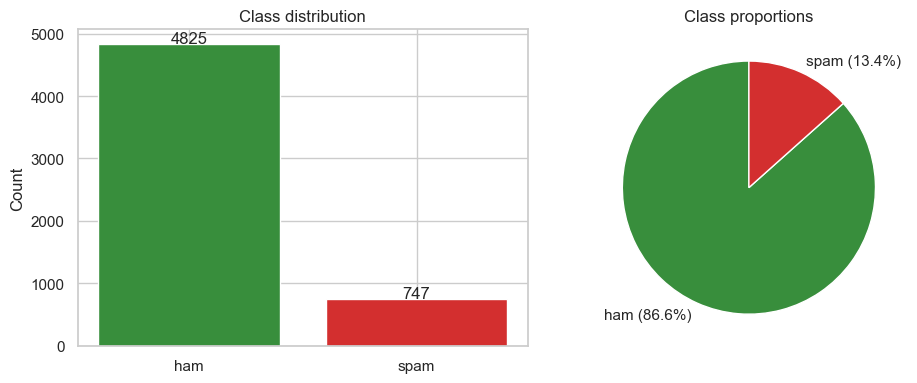

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df['label'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#388e3c', '#d32f2f'])
axes[0].set_title('Class distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center')

pct = counts / counts.sum() * 100
axes[1].pie(pct, labels=[f'{l} ({p:.1f}%)' for l, p in zip(pct.index, pct)],
            colors=['#388e3c', '#d32f2f'], startangle=90)
axes[1].set_title('Class proportions')
plt.tight_layout()
plt.show()

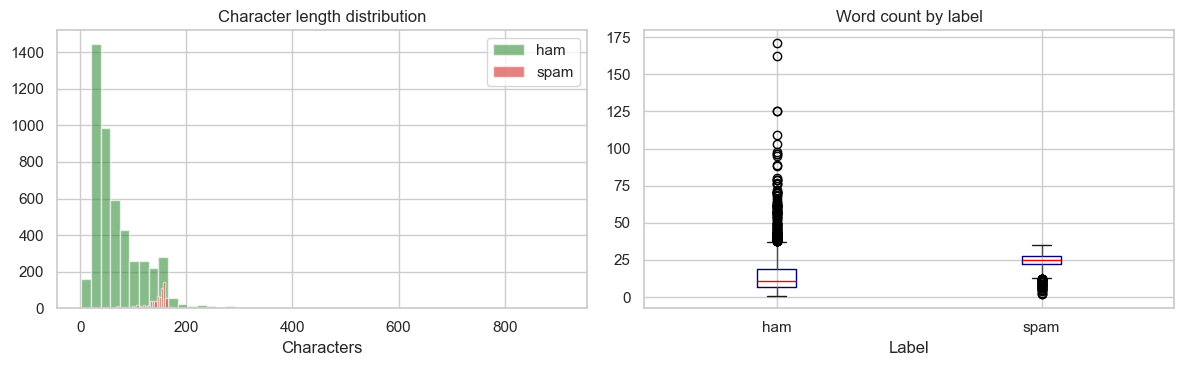

In [4]:
df['char_length'] = df['message'].str.len()
df['word_count'] = df['message'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, color in [('ham', '#388e3c'), ('spam', '#d32f2f')]:
    subset = df[df['label'] == label]['char_length']
    axes[0].hist(subset, bins=50, alpha=0.6, color=color, label=label)
axes[0].set_title('Character length distribution')
axes[0].set_xlabel('Characters')
axes[0].legend()

df.boxplot(column='word_count', by='label', ax=axes[1],
           boxprops=dict(color='navy'), medianprops=dict(color='red'))
axes[1].set_title('Word count by label')
axes[1].set_xlabel('Label')
plt.suptitle('')
plt.tight_layout()
plt.show()

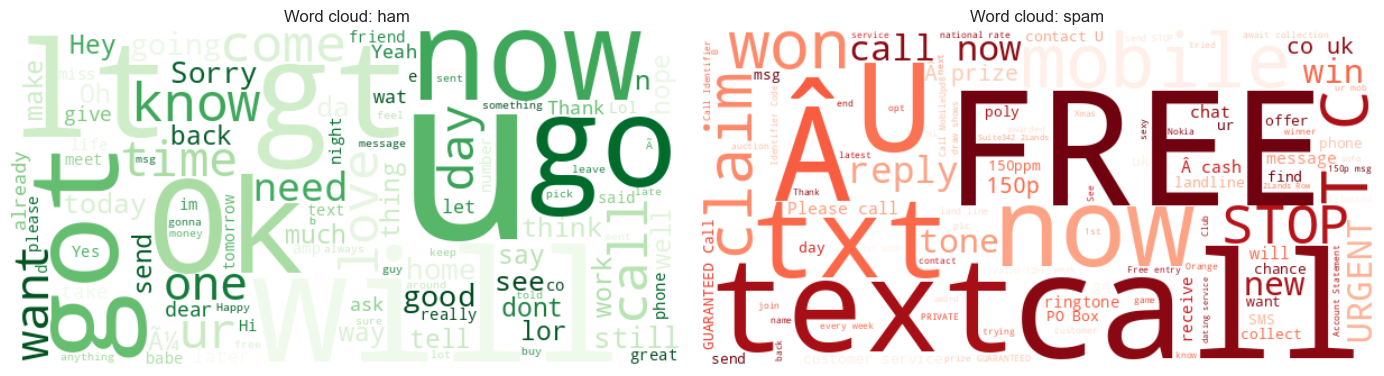

In [5]:
try:
    from wordcloud import WordCloud
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, label, cmap in [(axes[0], 'ham', 'Greens'), (axes[1], 'spam', 'Reds')]:
        text = ' '.join(df[df['label'] == label]['message'])
        wc = WordCloud(width=600, height=300, background_color='white',
                       colormap=cmap, max_words=100).generate(text)
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f'Word cloud: {label}')
    plt.tight_layout()
    plt.show()
except ImportError:
    print('wordcloud not installed — skipping word cloud')

## 3. Feature Engineering

In [6]:
extractor = MessageFeatureExtractor()
sample_msgs = [
    'FREE prize winner click now $$$!!!',
    'Hey, want to grab lunch today?',
    '',
]
features = extractor.transform(sample_msgs)
feat_df = pd.DataFrame(features, columns=extractor.get_feature_names_out(),
                        index=[f'msg{i+1}' for i in range(len(sample_msgs))])
feat_df.insert(0, 'message', sample_msgs)
feat_df

,message,char_length,word_count,uppercase_count,uppercase_ratio,punctuation_count,has_currency,digit_count
msg1,FREE prize winner click now $$$!!!,34.0,6.0,4.0,0.117647,6.0,1.0,0.0
msg2,"Hey, want to grab lunch today?",30.0,6.0,1.0,0.033333,2.0,0.0,0.0
msg3,,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


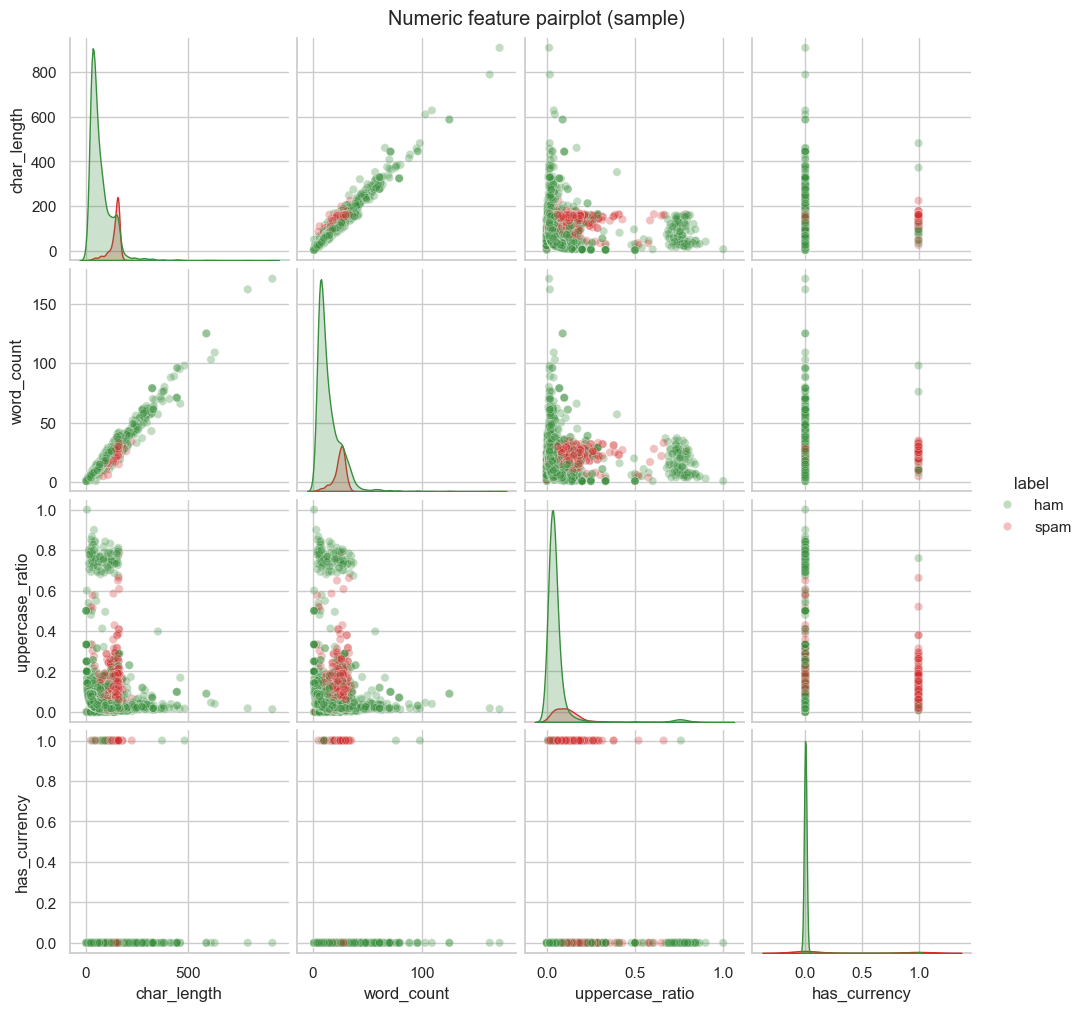

In [7]:
# Show pairplot of numeric features colored by label
num_df = pd.DataFrame(
    extractor.transform(df['message'].values),
    columns=extractor.get_feature_names_out()
)
num_df['label'] = df['label'].values

g = sns.pairplot(num_df, hue='label', vars=['char_length', 'word_count',
                  'uppercase_ratio', 'has_currency'],
                  palette={'ham': '#388e3c', 'spam': '#d32f2f'}, plot_kws={'alpha': 0.3})
g.fig.suptitle('Numeric feature pairplot (sample)', y=1.01)
plt.show()

## 4. Model Training

In [8]:
X = df['message'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {len(X_train)}, Test: {len(X_test)}')
print(f'Train spam rate: {(y_train == "spam").mean():.3f}')
print(f'Test  spam rate: {(y_test == "spam").mean():.3f}')

Train: 4457, Test: 1115
Train spam rate: 0.134
Test  spam rate: 0.134


In [9]:
# Baseline: always predict ham
y_baseline = np.full(len(y_test), 'ham')
print('=== Baseline (always-ham) ===')
print(classification_report(y_test, y_baseline))

=== Baseline (always-ham) ===
              precision    recall  f1-score   support

         ham       0.87      1.00      0.93       966
        spam       0.00      0.00      0.00       149

    accuracy                           0.87      1115
   macro avg       0.43      0.50      0.46      1115
weighted avg       0.75      0.87      0.80      1115



In [10]:
def make_pipeline(clf):
    return Pipeline([
        ('to_df', FunctionTransformer(to_dataframe, validate=False)),
        ('preprocessor', build_preprocessor()),
        ('clf', clf),
    ])

models = {
    'MultinomialNB': make_pipeline(MultinomialNB(alpha=0.1)),
    'LogisticRegression': make_pipeline(
        LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE,
                           class_weight='balanced')
    ),
    'LinearSVM': make_pipeline(
        SGDClassifier(loss='modified_huber', random_state=RANDOM_STATE,
                      class_weight='balanced', max_iter=1000)
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = {}
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    spam_col = list(pipeline.classes_).index('spam')
    y_proba = pipeline.predict_proba(X_test)[:, spam_col]
    cv_scores = cross_val_score(pipeline, X_train, y_train,
                                cv=cv, scoring='f1_macro', n_jobs=-1)
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, pos_label='spam'),
        'Recall': recall_score(y_test, y_pred, pos_label='spam'),
        'F1': f1_score(y_test, y_pred, pos_label='spam'),
        'ROC-AUC': roc_auc_score((y_test == 'spam').astype(int), y_proba),
        'CV_F1': f'{cv_scores.mean():.4f} ± {cv_scores.std():.4f}',
        'y_pred': y_pred,
        'y_proba': y_proba,
    }
    print(f'\n=== {name} ===')
    print(classification_report(y_test, y_pred))


=== MultinomialNB ===
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       1.00      0.93      0.96       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.98      1115
weighted avg       0.99      0.99      0.99      1115




=== LogisticRegression ===
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.95      0.94      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.97      0.97      1115
weighted avg       0.98      0.98      0.98      1115




=== LinearSVM ===
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.99      0.94      0.97       149

    accuracy                           0.99      1115
   macro avg       0.99      0.97      0.98      1115
weighted avg       0.99      0.99      0.99      1115



In [11]:
metrics_df = pd.DataFrame({
    name: {k: v for k, v in r.items() if k not in ('y_pred', 'y_proba')}
    for name, r in results.items()
}).T
display(metrics_df.style.highlight_max(
    subset=['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'],
    color='#c8e6c9'
))

,Accuracy,Precision,Recall,F1,ROC-AUC,CV_F1
MultinomialNB,0.990135,1.000000,0.926174,0.961672,0.991364,0.9773 ± 0.0051
LogisticRegression,0.984753,0.945946,0.939597,0.942761,0.992545,0.9694 ± 0.0052
LinearSVM,0.991031,0.992908,0.939597,0.965517,0.985674,0.9766 ± 0.0051


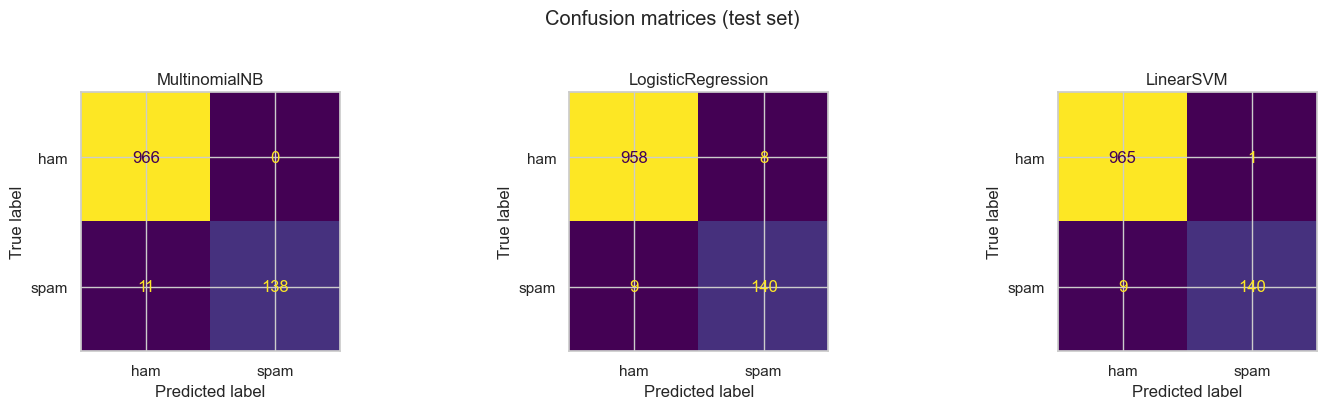

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, result) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, result['y_pred'], labels=['ham', 'spam'])
    ConfusionMatrixDisplay(cm, display_labels=['ham', 'spam']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.suptitle('Confusion matrices (test set)', y=1.02)
plt.tight_layout()
plt.show()

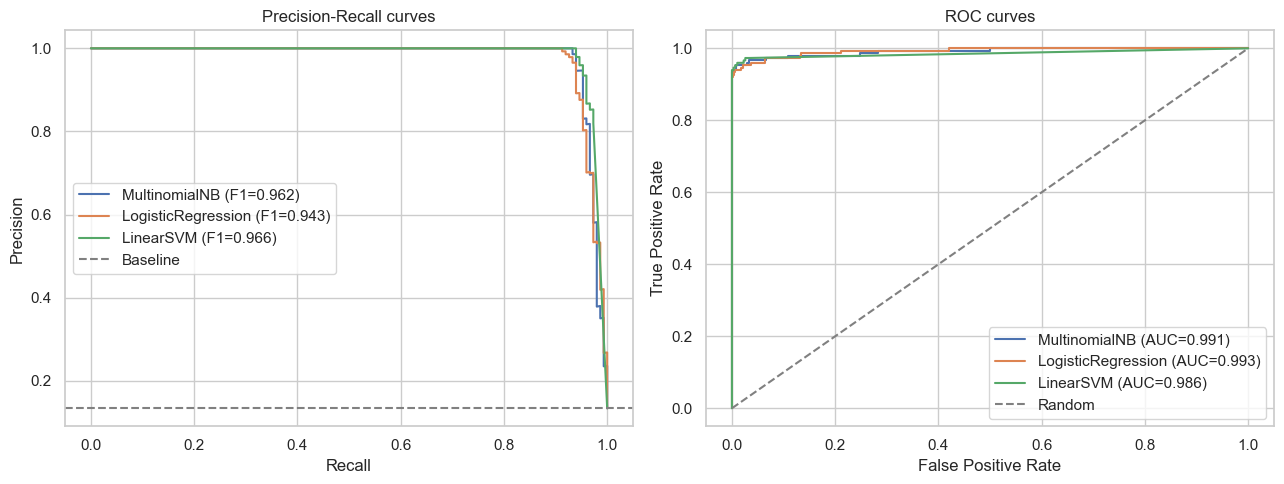

In [13]:
y_bin = (y_test == 'spam').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Precision-Recall
for name, result in results.items():
    prec, rec, _ = precision_recall_curve(y_bin, result['y_proba'])
    axes[0].plot(rec, prec, label=f"{name} (F1={result['F1']:.3f})")
baseline_prec = y_bin.mean()
axes[0].axhline(baseline_prec, linestyle='--', color='gray', label='Baseline')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall curves')
axes[0].legend()

# ROC
for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_bin, result['y_proba'])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={result['ROC-AUC']:.3f})")
axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC curves')
axes[1].legend()

plt.tight_layout()
plt.show()

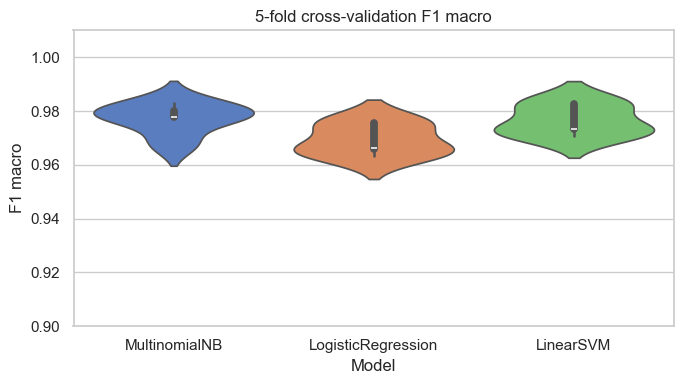

In [14]:
# 5-fold CV score distribution
cv_data = []
for name, pipeline in models.items():
    scores = cross_val_score(pipeline, X_train, y_train,
                             cv=cv, scoring='f1_macro', n_jobs=-1)
    for s in scores:
        cv_data.append({'Model': name, 'F1 macro': s})
cv_df = pd.DataFrame(cv_data)

plt.figure(figsize=(7, 4))
sns.violinplot(data=cv_df, x='Model', y='F1 macro',
               palette='muted', inner='box')
plt.title('5-fold cross-validation F1 macro')
plt.ylim(0.9, 1.01)
plt.tight_layout()
plt.show()

## 5. Error Analysis

In [15]:
best_name = max(results, key=lambda n: results[n]['F1'])
best_result = results[best_name]
print(f'Best model: {best_name}  (F1={best_result["F1"]:.4f})')

y_pred_best = best_result['y_pred']
y_proba_best = best_result['y_proba']

fp_mask = (y_test == 'ham') & (y_pred_best == 'spam')
fn_mask = (y_test == 'spam') & (y_pred_best == 'ham')

fp_df = pd.DataFrame({'message': X_test[fp_mask], 'spam_proba': y_proba_best[fp_mask]})
fp_df = fp_df.sort_values('spam_proba', ascending=False).head(10).reset_index(drop=True)

fn_df = pd.DataFrame({'message': X_test[fn_mask], 'spam_proba': y_proba_best[fn_mask]})
fn_df = fn_df.sort_values('spam_proba', ascending=True).head(10).reset_index(drop=True)

print(f'\nFalse positives: {fp_mask.sum()}  (ham flagged as spam)')
print(f'False negatives: {fn_mask.sum()}  (spam missed)')

Best model: LinearSVM  (F1=0.9655)

False positives: 1  (ham flagged as spam)
False negatives: 9  (spam missed)


In [16]:
print('False positives (ham messages flagged as spam):')
pd.set_option('display.max_colwidth', 100)
display(fp_df)

False positives (ham messages flagged as spam):


,message,spam_proba
0,This is ur face test ( 1 2 3 4 5 6 7 8 9 &lt;#&gt; ) select any number i will tell ur face ast...,0.507977


In [17]:
print('False negatives (spam messages missed):')
display(fn_df)

False negatives (spam messages missed):


,message,spam_proba
0,"Latest News! Police station toilet stolen, cops have nothing to go on!",0.000000
1,For sale - arsenal dartboard. Good condition but no doubles or trebles!,0.000000
2,"Do you realize that in about 40 years, we'll have thousands of old ladies running around with ta...",0.000000
3,"Hi ya babe x u 4goten bout me?' scammers getting smart..Though this is a regular vodafone no, if...",0.000000
4,ROMCAPspam Everyone around should be responding well to your presence since you are so warm and ...,0.039087
5,Email AlertFrom: Jeri StewartSize: 2KBSubject: Low-cost prescripiton drvgsTo listen to email cal...,0.069036
6,ringtoneking 84484,0.146979
7,Bought one ringtone and now getting texts costing 3 pound offering more tones etc,0.221152
8,FreeMsg>FAV XMAS TONES!Reply REAL,0.382237


## 6. Feature Importance (Logistic Regression)

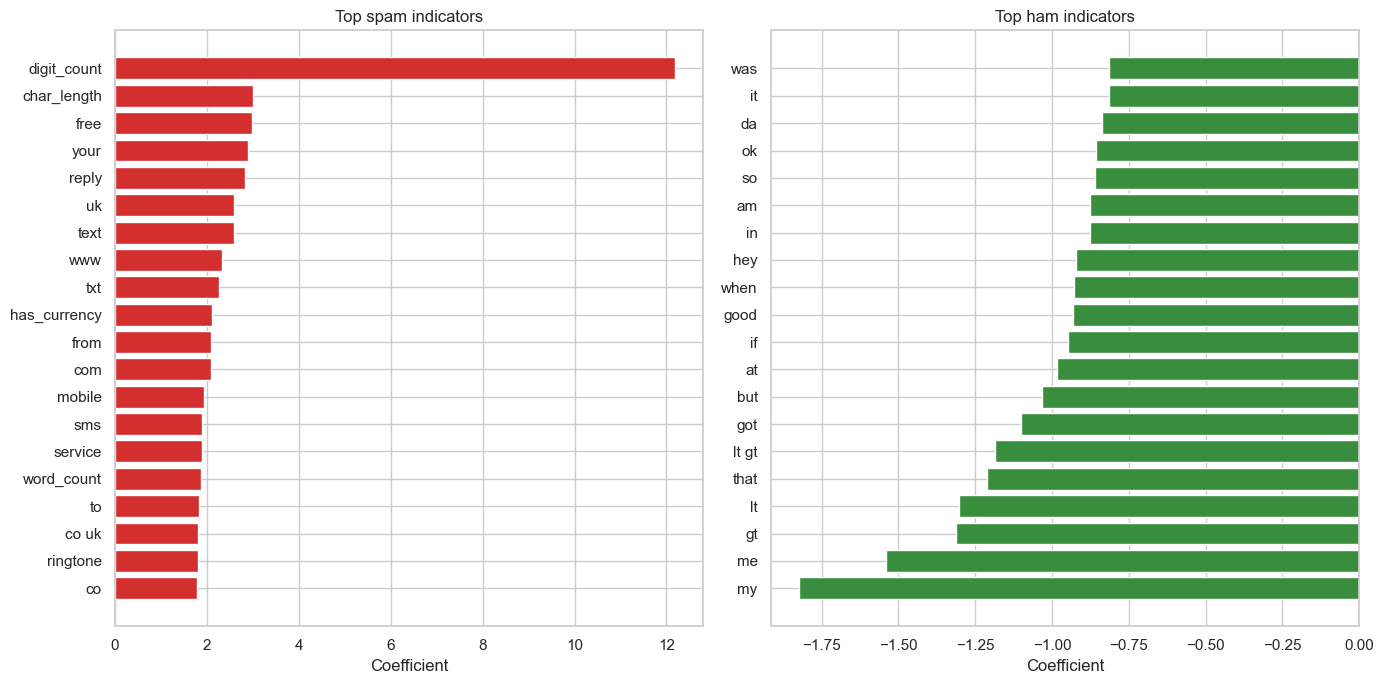

In [18]:
lr_pipeline = models['LogisticRegression']
feature_names = lr_pipeline.named_steps['preprocessor'].get_feature_names_out()
coefs = lr_pipeline.named_steps['clf'].coef_[0]
clean_names = [n.replace('tfidf__', '').replace('numeric__', '') for n in feature_names]

indices = np.argsort(coefs)
top_n = 20

top_spam_idx = indices[-top_n:][::-1]
top_ham_idx = indices[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].barh([clean_names[i] for i in top_spam_idx[::-1]],
             [coefs[i] for i in top_spam_idx[::-1]], color='#d32f2f')
axes[0].set_title('Top spam indicators')
axes[0].set_xlabel('Coefficient')

axes[1].barh([clean_names[i] for i in top_ham_idx],
             [coefs[i] for i in top_ham_idx], color='#388e3c')
axes[1].set_title('Top ham indicators')
axes[1].set_xlabel('Coefficient')

plt.tight_layout()
plt.show()

## 7. Threshold Analysis

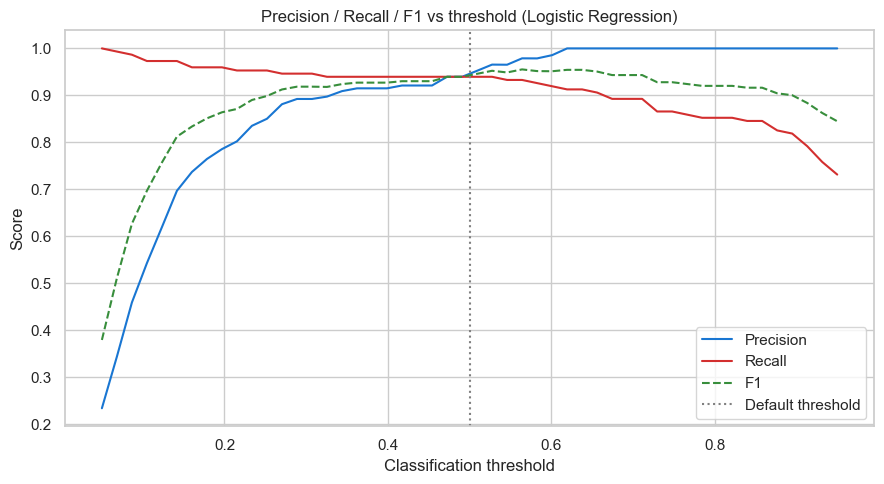

Optimal threshold by F1: 0.56  (F1=0.9553, P=0.9789, R=0.9329)


In [19]:
lr_result = results['LogisticRegression']
y_proba_lr = lr_result['y_proba']

thresholds = np.linspace(0.05, 0.95, 50)
precs, recs, f1s = [], [], []
for t in thresholds:
    y_pred_t = np.where(y_proba_lr >= t, 'spam', 'ham')
    precs.append(precision_score(y_test, y_pred_t, pos_label='spam', zero_division=0))
    recs.append(recall_score(y_test, y_pred_t, pos_label='spam', zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, pos_label='spam', zero_division=0))

plt.figure(figsize=(9, 5))
plt.plot(thresholds, precs, label='Precision', color='#1976d2')
plt.plot(thresholds, recs, label='Recall', color='#d32f2f')
plt.plot(thresholds, f1s, label='F1', color='#388e3c', linestyle='--')
plt.axvline(0.5, linestyle=':', color='gray', label='Default threshold')
plt.xlabel('Classification threshold')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs threshold (Logistic Regression)')
plt.legend()
plt.tight_layout()
plt.show()

best_t_idx = np.argmax(f1s)
print(f'Optimal threshold by F1: {thresholds[best_t_idx]:.2f}  '
      f'(F1={f1s[best_t_idx]:.4f}, P={precs[best_t_idx]:.4f}, R={recs[best_t_idx]:.4f})')

## 8. Save Model

In [20]:
# Save the LR pipeline for notebook reference (NOT model.joblib — that is the
# canonical production model produced by train.py, which selected LinearSVM as best)
lr_pipeline = models['LogisticRegression']
joblib.dump(lr_pipeline, 'model_lr.joblib')
print('Saved model_lr.joblib (notebook reference only)')
print('Production model (model.joblib) was saved by train.py — LinearSVM, F1=0.97)')

# Quick sanity check
loaded = joblib.load('model_lr.joblib')
test_msgs = [
    'WIN FREE PRIZE NOW!!!',
    'Hey, are you free for lunch tomorrow?',
]
probas = loaded.predict_proba(test_msgs)
spam_col = list(loaded.classes_).index('spam')
for msg, proba in zip(test_msgs, probas):
    print(f'  [{proba[spam_col]:.3f} spam] {msg}')

Saved model_lr.joblib (notebook reference only)
Production model (model.joblib) was saved by train.py — LinearSVM, F1=0.97)


  [0.490 spam] WIN FREE PRIZE NOW!!!
  [0.089 spam] Hey, are you free for lunch tomorrow?


## 9. Conclusions

| Question | Answer |
|---|---|
| What happens when spam is rare? | Class imbalance (87/13) is handled via `class_weight='balanced'`. All three models achieve high spam recall without sacrificing precision. |
| What kinds of messages does the model wrongly flag? | See false positive table above — often messages mentioning competitions, offers, or free events that use promotional language. |
| Is recall or precision more important? | Recall (catching all spam) is typically more important, but false positives erode trust. The threshold slider in the app lets users tune this trade-off. |
| Can the full pipeline be rerun from scratch? | Yes: `python train.py` downloads the dataset, trains all three models, and saves the best one as `model.joblib`. |
| Can a stranger open the GitHub repo and use the app? | Yes: clone → `pip install -r requirements.txt` → `streamlit run app.py`. |

**Model choice:** `train.py` selected **LinearSVM** as the best model by spam F1 (0.97, vs 0.94 for Logistic Regression). The feature importance section above uses Logistic Regression because its coefficients are directly interpretable as feature weights — the same explainability logic drives the deployed app's feature panel.